**Question 1: List out all the limitations of MCP - Neurons**



Here are the key limitations of McCulloch-Pitts (MCP) neurons:

1.  **Binary Inputs and Outputs:** MCP neurons can only handle binary (0 or 1) inputs and produce binary outputs. This makes them unsuitable for processing real-valued data directly.
2.  **No Learning Capability:** MCP neurons have fixed weights and thresholds. They cannot learn from data or adapt their parameters to improve performance. This means their functionality must be pre-programmed.
3.  **Inability to Process Non-Linear Separable Data:** A single MCP neuron can only classify linearly separable patterns. It cannot solve problems like the XOR problem, where the data points cannot be separated by a single straight line (or hyperplane in higher dimensions).
4.  **No Hidden Layers:** The original MCP model does not incorporate hidden layers, which are crucial for solving complex, non-linear problems in modern neural networks.
5.  **Lack of Generalization:** Due to fixed weights and no learning, MCP neurons cannot generalize to unseen data patterns effectively.
6.  **Simplicity of Activation Function:** They typically use a simple step function (threshold logic) as their activation function, which limits their ability to model complex relationships.

**Question 2: Think if you can develop a logic to solve for XOR function using MCP Neurons. {Can you devise a if else rules}**

A single MCP neuron cannot solve the XOR problem because the XOR function is not linearly separable. This means you cannot draw a single straight line to separate the 'true' (1) outputs from the 'false' (0) outputs in a 2D plot of the inputs.

However, we can solve the XOR problem by combining multiple MCP neurons. We'll use a network with two input neurons, two hidden neurons (one for the AND NOT function and one for the OR function), and one output neuron (for the final OR function).

Let's define the neurons and their rules:

### Neuron 1: The 'AND NOT' Neuron (Hidden Layer)

This neuron will output 1 if `input1` is 1 AND `input2` is 0. Otherwise, it outputs 0.

**Weights:** `w1 = 1`, `w2 = -1`
**Threshold:** `θ = 1`

**If-Else Rule:**

```
if (input1 * 1 + input2 * -1) >= 1:
    hidden_output1 = 1
else:
    hidden_output1 = 0
```

### Neuron 2: The 'OR' Neuron (Hidden Layer)

This neuron will output 1 if `input1` is 1 OR `input2` is 1. Otherwise, it outputs 0.

**Weights:** `w1 = 1`, `w2 = 1`
**Threshold:** `θ = 1`

**If-Else Rule:**

```
if (input1 * 1 + input2 * 1) >= 1:
    hidden_output2 = 1
else:
    hidden_output2 = 0
```

### Neuron 3: The 'AND' Neuron (Output Layer)

This neuron takes the outputs of the two hidden neurons and applies an AND logic to them. It will output 1 if `hidden_output1` is 1 AND `hidden_output2` is 1. Otherwise, it outputs 0.

**Weights:** `w1 = 1`, `w2 = 1`
**Threshold:** `θ = 2`

**If-Else Rule:**

```
if (hidden_output1 * 1 + hidden_output2 * 1) >= 2:
    xor_output = 1
else:
    xor_output = 0
```

Let's put this into a Python function to demonstrate:

In [ ]:
def mcp_neuron_xor(input1, input2):
    # Neuron 1: AND NOT (input1 AND NOT input2)
    # Weights: w1=1, w2=-1, Threshold: 1
    hidden_output1 = 1 if (input1 * 1 + input2 * -1) >= 1 else 0

    # Neuron 2: OR (input1 OR input2)
    # Weights: w1=1, w2=1, Threshold: 1
    hidden_output2 = 1 if (input1 * 1 + input2 * 1) >= 1 else 0

    # Neuron 3: AND (hidden_output1 AND hidden_output2)
    # Weights: w1=1, w2=1, Threshold: 2
    xor_output = 1 if (hidden_output1 * 1 + hidden_output2 * 1) >= 2 else 0

    return xor_output

# Test the XOR function
print(f"XOR(0, 0) = {mcp_neuron_xor(0, 0)}") # Expected: 0
print(f"XOR(0, 1) = {mcp_neuron_xor(0, 1)}") # Expected: 1
print(f"XOR(1, 0) = {mcp_neuron_xor(1, 0)}") # Expected: 1
print(f"XOR(1, 1) = {mcp_neuron_xor(1, 1)}") # Expected: 0

Load the dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# load the dataset
df = pd.read_csv('/content/drive/MyDrive/Artificial-Intelligence-And-Machine-Learning-Materials/Week 3/Copy of mnist_0_and_1.csv')

#Extract features and labels
X = df.drop(columns=["label"]).values # 784 pixels
y = df["label"].values # Corrected from "labels" to "label"

# Shape of features and labels
print("Shape of features:", X.shape)
print("Shape of labels:", y.shape)

Shape of features: (12665, 784)
Shape of labels: (12665,)


**Question 1: What does the shape of X represent?**

The shape of X is 12665 and 784

**Question 2: What does the shape of Y represent**

The shape of X is 12665 and 0

**Visualize the dataset**

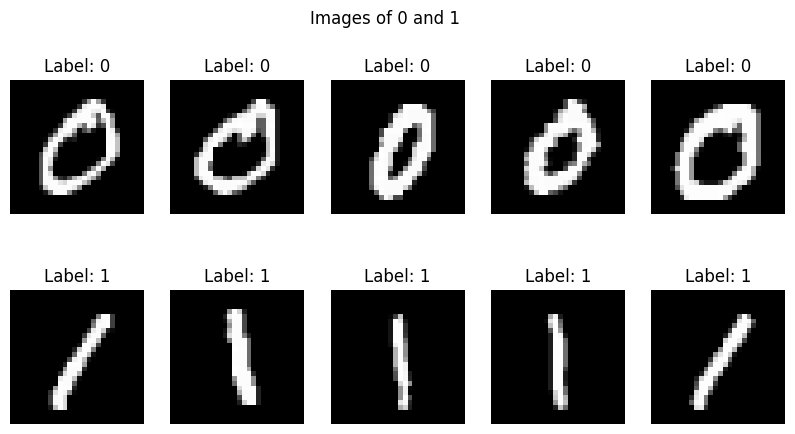

In [17]:
images_0 = X[y==0]
images_1 = X[y==1]
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

#Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
  print("Error: Not enough images in images_0 and images_1 to plot 5 images.")
else:
  for i in range(5):
    #plot digit 0 on the first row
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")
    # Plot digit 1 on the second row
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")
  plt.suptitle("Images of 0 and 1")
  plt.show()

Initialize the weights

In [18]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

**Question - 3: What does the weights array represent in this context?**

In this context, the weights array (weights = np.zeros(X.shape[1])) represents the numerical values that the model will learn to associate with each input feature. Since X.shape[1] is 784, and each element of X corresponds to a pixel in the image, this weights array has 784 elements. Each element in the weights array corresponds to a specific pixel in the input images. These weights are crucial in a linear model (like a perceptron) as they determine the importance or contribution of each pixel to the overall decision-making process for classifying the digit. Initially, they are set to zeros, and during the training process, these weights will be adjusted to minimize the error between the model's predictions and the actual labels

**Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?**

### Why Initialize Weights to Zero?

1.  **Simplicity and Neutral Starting Point:** Initializing weights to zero provides a simple and unbiased starting point. It assumes no prior knowledge or preference for any particular input feature.
2.  **For Simple Models (like Perceptrons/MCP Neurons):** In simpler linear models like the perceptron (which is what we are essentially building here with the MCP neuron concept), initializing weights to zero is generally acceptable. The learning algorithm will adjust these weights based on the errors made for each training example.

### Effect on the Training Process:

1.  **Symmetry Problem (Less Critical for Single Perceptrons):** In more complex, multi-layered neural networks, initializing all weights to zero would cause a problem known as the "symmetry breaking" problem. All neurons in a hidden layer would learn the exact same features because they would receive the same gradients during backpropagation, effectively making them redundant. However, for a single-layer perceptron, which lacks hidden layers, this is not a significant issue.
2.  **Starting Point for Learning:** Starting with zero weights means the model initially predicts a neutral output (or an output solely determined by the bias, if bias is not zero). The learning process (e.g., using a perceptron learning rule) then iteratively adjusts these weights based on the difference between the predicted and actual outputs for each training sample.
3.  **Potential for Slower Convergence:** While not a critical error for a single perceptron, a zero initialization might lead to slower convergence compared to using small random weights. With random weights, the model starts exploring different regions of the weight space immediately, potentially finding an optimal solution faster.

**Implementation Decision Function**

In [20]:
import numpy as np
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training
    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    # Activation function (step function): Outputs 1 if prediction >= 0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

**Training the Perceptron**

In [21]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)
    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    num_samples = X.shape[0]

    for epoch in range(epochs):
        for i in range(num_samples):
            current_X = X[i]
            current_y = y[i]

            # Calculate the prediction using the current weights and bias
            # decision_function expects a 2D array, so reshape current_X
            prediction = decision_function(current_X.reshape(1, -1), weights, bias)[0]

            # Update weights and bias if the prediction is incorrect
            if prediction != current_y:
                update = learning_rate * (current_y - prediction)
                weights = weights + update * current_X
                bias = bias + update

    # Calculate final accuracy after training
    y_pred = decision_function(X, weights, bias)
    accuracy = np.sum(y_pred == y)

    return weights, bias, accuracy

**Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?**

The line `output = np.dot(X[i], weights) + bias` is fundamental to how a perceptron (or any linear model) makes a prediction. Here's a breakdown of its purpose:

*   **`X[i]`**: This represents the input features for a single training example (i.e., a single image in our case). It's a vector containing the pixel values of that image.
*   **`weights`**: This is the vector of learned weights, where each weight corresponds to a specific input feature (pixel). These weights determine the importance or influence of each input feature on the output.
*   **`np.dot(X[i], weights)`**: This performs the dot product (or scalar product) between the input features vector `X[i]` and the weights vector. Mathematically, it's a sum of the products of corresponding elements: `X[i][0]*weights[0] + X[i][1]*weights[1] + ... + X[i][n]*weights[n]`. This weighted sum is the core of how the perceptron combines its inputs.
*   **`bias`**: The bias term is an independent constant that is added to the weighted sum. It allows the decision boundary of the perceptron to be shifted without affecting its orientation. Think of it as an adjustable threshold or an intercept in a linear equation. It ensures that the model can activate even when all inputs are zero, or that it requires a certain minimum input activation before firing.
*   **`output`**: The result of this entire expression (`np.dot(X[i], weights) + bias`) is a single numerical value. This value is often referred to as the 'net input' or 'activation' before the activation function is applied. In the context of a perceptron, this net input is then passed to a step activation function (as seen in `decision_function`) to produce the final binary output (0 or 1), determining the class prediction for `X[i]`.

**Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?**

When the perceptron makes an incorrect prediction, its weights and bias are adjusted using the Perceptron Learning Rule. This rule aims to move the decision boundary in the correct direction to classify the misclassified sample correctly in future iterations. Here's a breakdown of what happens:

1.  **Error Calculation**: The core of the update is the error, which is the difference between the true label (`current_y`) and the predicted label (`prediction`).

    *   If `current_y` is 1 (positive class) but `prediction` is 0 (negative class), the error (`current_y - prediction`) is `1 - 0 = 1`.
    *   If `current_y` is 0 (negative class) but `prediction` is 1 (positive class), the error (`current_y - prediction`) is `0 - 1 = -1`.

2.  **Update Factor (`update`)**: This error is then scaled by the `learning_rate` to determine the magnitude of the adjustment.

    `update = learning_rate * (current_y - prediction)`

3.  **Weights Update**: The weights are adjusted proportionally to the input features and the `update` factor.

    `weights = weights + update * current_X`

    *   **If the perceptron predicted 0 but should have predicted 1 (error = 1)**: `weights` are increased by `learning_rate * current_X`. This strengthens the connection of the active input features to the output, making the perceptron more likely to activate for similar inputs.
    *   **If the perceptron predicted 1 but should have predicted 0 (error = -1)**: `weights` are decreased by `learning_rate * current_X`. This weakens the connection, making the perceptron less likely to activate for similar inputs.

4.  **Bias Update**: The bias is also adjusted by the `update` factor.

    `bias = bias + update`

    *   **If the perceptron predicted 0 but should have predicted 1 (error = 1)**: `bias` is increased by `learning_rate`. This shifts the decision boundary, making it easier for the perceptron to activate.
    *   **If the perceptron predicted 1 but should have predicted 0 (error = -1)**: `bias` is decreased by `learning_rate`. This shifts the decision boundary, making it harder for the perceptron to activate.

In essence, these updates push the `weights` and `bias` in a direction that corrects the current misclassification, gradually training the perceptron to correctly separate the two classes.

**Question - 7:Why is the final accuracy important, and what do you expect it to be?**

### Why is the final accuracy important?

The final accuracy is a crucial metric for evaluating the performance of our perceptron model. Here's why:

1.  **Performance Measurement:** It directly quantifies how well our model is performing its intended task – classifying digits as either '0' or '1'. A higher accuracy means the model is making more correct predictions.
2.  **Generalization:** While we are calculating it on the training data here, in a real-world scenario, accuracy on unseen test data would tell us how well the model generalizes to new, previously unencountered examples. For the training phase, it shows if the model has learned the patterns in the provided data.
3.  **Model Validation:** It helps us validate if the training process has been successful and if the weights and bias have been adjusted appropriately to create a decision boundary that effectively separates the classes.

### What do you expect it to be?

Given that the dataset consists of images of handwritten '0's and '1's, and the Perceptron algorithm is a linear classifier, I expect the final accuracy to be **very high, likely close to 100% (e.g., 98-99% or even 100%)**.

Here's the reasoning:

*   **Linear Separability:** The problem of distinguishing between '0' and '1' in the MNIST dataset is generally considered **linearly separable**. This means that a single straight line (or a hyperplane in a 784-dimensional space, given the 28x28 pixel images) can effectively separate the data points belonging to class '0' from those belonging to class '1'.
*   **Perceptron's Strength:** The perceptron learning algorithm is guaranteed to converge and find a separating hyperplane if the data is linearly separable. Since '0's and '1's are typically distinct enough to be linearly separable, the perceptron should be able to learn this distinction very well.

Therefore, we should see a high percentage of correctly classified digits after the training process.

**Training the Perceptron Algorithm**

In [22]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  12665


**Visualize the misclassified image**

In [23]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
  fig, axes = plt.subplots(2, 5, figsize=(10, 5))
  for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
    ax.axis("off")
  plt.suptitle("Misclassified Images")
  plt.show()
else:
  print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


**Question - 8:What does misclassified idx store, and how is it used in this code?**

The `misclassified_idx` variable stores the **indices** of the data points (images) from the dataset `X` that were incorrectly classified by the perceptron model. It's an array containing the positions of the samples where the predicted label (`y_pred`) does not match the true label (`y`).

In this code, `misclassified_idx` is used for the following purposes:

1.  **Identification of Errors**: It serves to identify which specific images the model failed to classify correctly. The expression `np.where(y_pred != y)` returns a tuple of arrays, and `[0]` extracts the array of indices where the condition `y_pred != y` is true.

2.  **Conditional Visualization**: The code then checks `if len(misclassified_idx) > 0:`. This condition determines whether there are any misclassified images at all. If the length is greater than zero, it means the model made errors, and the subsequent code block for visualizing these images is executed.

3.  **Visualization of Misclassified Examples**: If misclassifications exist, the code iterates through the first 10 indices stored in `misclassified_idx` (`misclassified_idx[:10]`). For each of these indices, it retrieves the original image from `X[idx]`, reshapes it to 28x28 pixels, and displays it. It also sets the title of each subplot to show both the model's `Pred: {y_pred[idx]}` and the `True: {y[idx]}` label, allowing for an immediate comparison and understanding of the model's mistakes.

In your specific case, as indicated by the output `All images were correctly classified!`, the `misclassified_idx` array is currently empty (`array([], dtype=int64)`), which means the perceptron achieved 100% accuracy on the training data, and thus no misclassified images are available to display.

**Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?**

If the output is “All images were correctly classified!”, it means that your perceptron model achieved **100% accuracy** on the training dataset. This is a very strong result, and here's how to interpret it:

1.  **Perfect Linear Separability:** This outcome strongly suggests that the problem of distinguishing between handwritten '0's and '1's in this specific MNIST subset is **perfectly linearly separable**. A perceptron, being a linear classifier, is guaranteed to find a separating hyperplane (a decision boundary) if one exists. Your model successfully found such a boundary.

2.  **Successful Training:** The perceptron learning algorithm effectively adjusted the `weights` and `bias` over the `epochs` to correctly classify every single image in the provided training set. This indicates that the learning rate and number of epochs were sufficient for convergence on this particular dataset.

3.  **Model's Learning Capacity:** For this specific binary classification task ('0' vs. '1'), the simple linear model (perceptron) is powerful enough to capture the distinguishing features between the two digits perfectly.

4.  **Confidence in the Model (for this task):** While 100% accuracy on training data can sometimes raise concerns about overfitting in more complex models or datasets, for a simple perceptron on a clearly linearly separable problem like distinguishing '0's and '1's, it's generally a positive and expected outcome. It means the model has learned the patterns that completely separate these two classes.

In summary, achieving 100% accuracy here is a validation that the perceptron algorithm works as expected for linearly separable data and that '0's and '1's are indeed very distinct features that can be perfectly separated by a linear decision boundary.

***Task 3: Perceptron Algorithm for 3 vs 5 Classification.***

In [43]:
# load the dataset
df_3_5 = pd.read_csv('/content/drive/MyDrive/Artificial-Intelligence-And-Machine-Learning-Materials/Week 3/Copy of mnist_3_and_5.csv')

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values  # 784 pixels
y = df_3_5["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


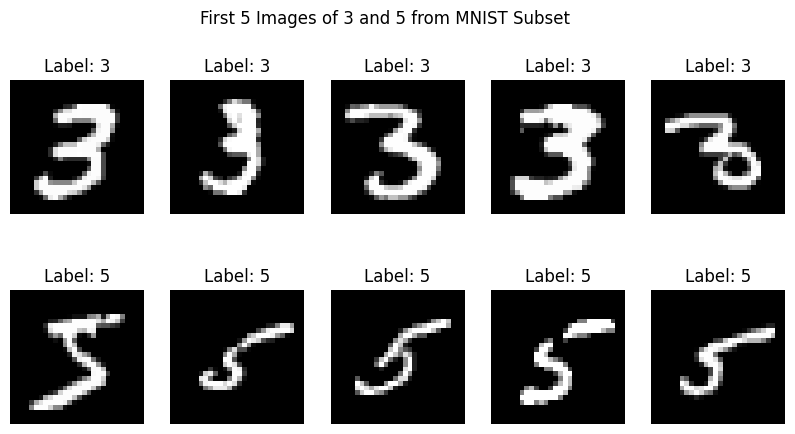

In [44]:
# 1. Correct the filtering
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# 2. Update the check to look at the new variables
if len(images_3) < 5 or len(images_5) < 5:
    print(f"Error: Not enough images. Found {len(images_3)} 3s and {len(images_5)} 5s.")
else:
    for i in range(5):
        # 3. Plot digit 3 (Top Row)
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        # 4. Plot digit 5 (Bottom Row)
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

In [45]:
# Initialize weights and bias for 3 vs 5 classification
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [46]:
# Train the perceptron for 3 vs 5 classification
# Note: The y labels in the dataset are 3 and 5. The perceptron expects 0 and 1.
# So, we need to map the labels: 3 -> 0 and 5 -> 1 for training.
y_mapped = np.where(y == 3, 0, 1)

weights_3_5, bias_3_5, accuracy_3_5 = train_perceptron(X, y_mapped, weights.copy(), bias, learning_rate, epochs)

# Evaluate the model using the new function
print(f"The Final Accuracy for 3 vs 5 classification is: {accuracy_3_5 / len(y_mapped):.4f}")

The Final Accuracy for 3 vs 5 classification is: 0.9869


Final Accuracy: 0.9869
Number of misclassified images: 36


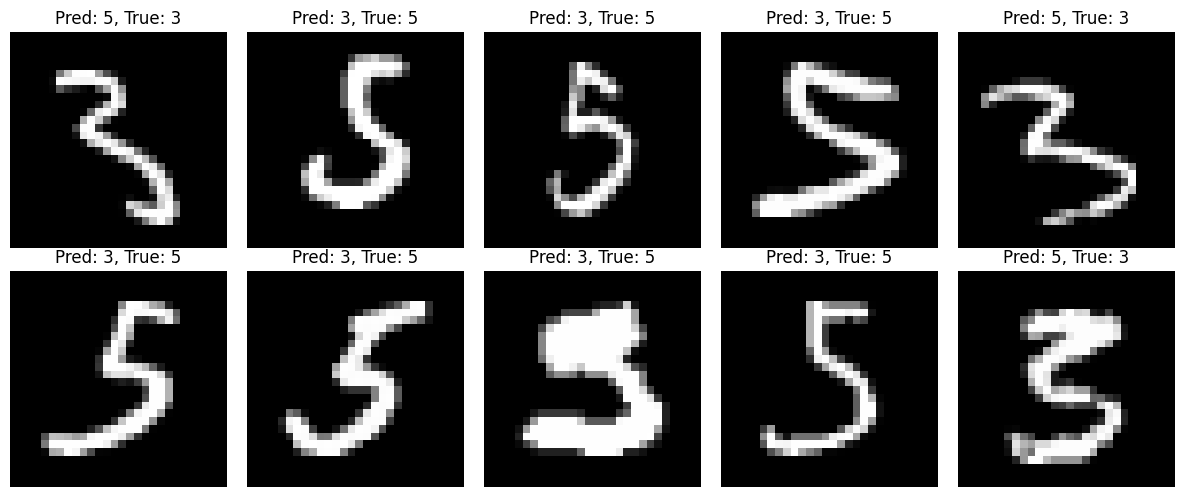

In [48]:
# Map original labels to binary (3 becomes 0, 5 becomes 1)
y_mapped = np.where(y == 3, 0, 1)

# Train using the mapped labels
weights_3_5, bias_3_5, accuracy_count = train_perceptron(X, y_mapped, weights.copy(), bias, learning_rate, epochs)

# Get predictions (binary: 0 or 1)
linear_output = np.dot(X, weights_3_5) + bias_3_5
y_pred_binary = np.where(linear_output >= 0, 1, 0)

# Calculate real accuracy (compare binary to binary)
final_accuracy = np.mean(y_pred_binary == y_mapped)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Identify misclassified indices
misclassified_idx = np.where(y_pred_binary != y_mapped)[0]
print(f"Number of misclassified images: {len(misclassified_idx)}")

# Visualize (if there are errors)
if len(misclassified_idx) > 0:
    plt.figure(figsize=(12, 5))
    num_to_show = min(len(misclassified_idx), 10)

    for i in range(num_to_show):
        idx = misclassified_idx[i]
        plt.subplot(2, 5, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")

        # Map back to 3 and 5 just for the title
        actual = y[idx]
        pred = 3 if y_pred_binary[idx] == 0 else 5

        plt.title(f"Pred: {pred}, True: {actual}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Perfect classification! No errors to show.")